# T019 · Molecular dynamics simulation

**Note:** This talktorial is a part of TeachOpenCADD, a platform that aims to teach domain-specific skills and to provide pipeline templates as starting points for research projects.

Authors:

- Pietro Gerletti, CADD seminar 2020, Charité/FU Berlin
- Mareike Leja, 2020/21, Internship at [Volkamer Lab, Charité](https://volkamerlab.org/)
- Jeffrey R Wagner, 2020, [Open Force Field Consortium](https://openforcefield.org/)
- David Schaller, 2020/21, [Volkamer Lab, Charité](https://volkamerlab.org/)
- Andrea Volkamer, 2020/21, [Volkamer Lab, Charité](https://volkamerlab.org/)

__Note__

This talktorial was based on a combination of 
- https://openmm.github.io/openmm-cookbook/dev/notebooks/tutorials/getting_started.html 
- mixed with teachopencadd talktorials 19 and 20 

## Aim of this talktorial

In this talktorial, we will learn how to set-up a simple molecular dynamics (MD) simulation and how to analyse the simulation results. We will use lysozyme as example protein. 

### Contents in *Theory*

- Molecular dynamics
- Force fields
- Boundary conditions
- MD simulations and drug design
- EGFR kinase

### Contents in *Practical*

- Import dependencies
- Download coordinate file
- Prepare the protein 
- MD simulation set up
  - Force field
  - System
- Perform the MD simulation
- Analysis of the results

### References

- Review on the impact of MD simulations in drug discovery ([_J Med Chem_ (2016), **59**(9), 4035‐4061](https://doi.org/10.1021/acs.jmedchem.5b01684))
- Review on the physics behind MD simulations and best practices ([_Living J Comp Mol Sci_ (2019), **1**(1), 5957](https://doi.org/10.33011/livecoms.1.1.5957))
- Review on force fields ([_J Chem Inf Model_ (2018), **58**(3), 565-578](https://doi.org/10.1021/acs.jcim.8b00042))
- Review on EGFR in cancer ([_Cancers (Basel)_ (2017), **9**(5), 52](https://dx.doi.org/10.3390%2Fcancers9050052))
- Summarized statistical knowledge from Pierre-Simon Laplace ([Théorie Analytique des Probabilités _Gauthier-Villars_ (1820), **3**)](https://archive.org/details/uvrescompltesde31fragoog/page/n15/mode/2up)
- Inspired by a notebook form Jaime Rodríguez-Guerra ([github](https://github.com/jaimergp/uab-msc-bioinf/blob/master/MD%20Simulation%20and%20Analysis%20in%20a%20Notebook.ipynb))
- Repositories of [OpenMM](https://github.com/openmm/openmm) and [OpenMM Forcefields](https://github.com/openmm/openmmforcefields), [RDKit](https://github.com/rdkit/rdkit), [PyPDB](https://github.com/williamgilpin/pypdb), [MDTraj](https://github.com/mdtraj/mdtraj), [PDBFixer](https://github.com/openmm/pdbfixer)
- Wikipedia articles about [MD simulations](https://en.wikipedia.org/wiki/Molecular_dynamics), [AMBER](https://en.wikipedia.org/wiki/AMBER) and [force fields](https://en.wikipedia.org/wiki/Force_field_(chemistry)) in general

## Theory

### Molecular dynamics

Molecular dynamics is a computational method analyzing the movements and interactions of atoms and molecules of a defined system. The method stems from theoretical physics, where it was developed in the 1950s (Alder and Wainwright in [_J Chem Phys_ (1959), **31**(2), 459](https://doi.org/10.1063/1.1730376)), although the ideas behind it can be dated much earlier:

> An intelligence which could, at  any moment, comprehend all the forces by  which nature is animated and the  respective positions of the  beings of which it is  composed, and moreover, if this intelligence were far-reaching enough to subject these data to  analysis, it would encompass in that formula both the movements of the  largest bodies in  the universe and those of the lightest atom: to it nothing would be uncertain, and the  future, as well as the past, would be present to its eyes. The human mind offers us, in the perfection which it has  given to  astronomy, a faint sketch of this intelligence. (Pierre-Simon Laplace, 1820)


Let us just take this statement by Laplace as the ideological substrate underneath molecular dynamics simulations. In other terms, we can approximate the behavior of a physical system by knowing the characteristics of its components and applying Newton's laws of motion. By solving the equations of motion, we can obtain a molecular trajectory of the system, which is a series of snapshots with the positions and velocities of all its particles, as well as its potential energy. To do so, we define functions, called force fields, which provide an approximate description of all the forces applied to each particle in the system. We then use numerical integrators to solve the initial value problem for the system and obtain the trajectory. As it sounds, the process requires quite a bit of processing power and it was only few years ago that MD started seeing a more widespread use, especially in the field of computational chemistry and biology, as well as in drug discovery ([_J Med Chem_ (2016), **59**(9), 4035‐4061](https://doi.org/10.1021/acs.jmedchem.5b01684)).

![MD_rotor_250K_1ns.gif](https://github.com/volkamerlab/teachopencadd/raw/d1ded86bb2c82ef088cc5145d0bcb997f6eab7dd/teachopencadd/talktorials/018_md_simulation/images/MD_rotor_250K_1ns.gif)

**Figure 1**: Molecular dynamics simulation of the rotation of a supramolecule composed of three molecules in a confined nanoscopic pore (Palma et al. via [Wikimedia](https://commons.wikimedia.org/w/index.php?curid=34866205)).

### Force fields



Force fields describe the forces between atoms within and between molecules. They are parametric equations with components for different forces (bond stretching, van-der-Waals and more). The parameter values are usually derived experimentally and change for each MD scenario, depending on the molecules involved and the simulation settings. The result is a mathematical description of the energy landscape of the system, in which the forces acting on each particle result from the gradient of the potential energy with respect to the coordinates of the atoms.

Several force fields are available, each with its own characteristics ([_J Chem Inf Model_ (2018), **58**(3), 565-578](https://doi.org/10.1021/acs.jcim.8b00042)). In this notebook, we will use a member of the AMBER force field family, which are widely used for MD simulations of proteins. Their functional form is:

$$V(r^N) = \sum_{i \in  bonds}k_{bi} (l_i-l^0_i)^2 + \sum_{i \in  angles}k_{ai}(\theta_i - \theta^0_i)^2 + \sum_{i\in torsions} \sum_n \frac{1}{2} V_i^n[1+cos(nw_i-\gamma_i)]$$
$$+ \sum_{j=1}^{N-1}\sum_{I=j+1}^{N} f_{ij}\in ij [(\frac{r^0_{ij}}{r_{ij}})^{12}-2(\frac{r^0_{ij}}{r_{ij}})^{6}]+\frac{q_iq_j}{4\pi \in_0 r_{ij}}$$

The formula consists of a sum of different components. The first three components contain information about bond lengths, angles and torsions (intramolecular forces). The last component describes intermolecular, non-bonded forces like van-der-Waals forces and electrostatic interactions. The various parameters, denoted by a superscript 0, depend on the force field used and vary between all members of the AMBER force field family. Note that these force fields assume fixed-charge particles and do not allow polarization, nor do they consider how a local charge influences its surroundings. 

The following visual representation of force fields components shows the same concepts in a more intuitive way.

![MM_PEF.png](https://github.com/volkamerlab/teachopencadd/raw/d1ded86bb2c82ef088cc5145d0bcb997f6eab7dd/teachopencadd/talktorials/018_md_simulation/images/MM_PEF.png)

**Figure 2**: Components of a molecular mechanics force field (Edboas via [Wikimedia](https://commons.wikimedia.org/w/index.php?curid=4194424)).

### Boundary conditions

Often, molecular systems are simulated in a box filled with solvent such as water. These boxes are of finite size, which results in problems for molecules at or near the box boundaries. With which molecules should those interact? Periodic boundary conditions can avoid such boundary artifacts by simulating a theoretically infinite system. Molecules at one boundary of the box thereby interact with molecules at the boundary on the other side of the box. This mimics a situation, in which the simulation box is surrounded by replicas of itself. When visualizing such MD simulations, one can often observe that particles leave the box at one side (Fig. 3). However, they re-appear at the same time on the other side of the box with the same velocity. For simulations under periodic boundary conditions, it is recommended to use a simulation box large enough, so that the simulated macromolecule does not come into contact with neighboring images of itself.

![MD_water.gif](https://github.com/volkamerlab/teachopencadd/raw/d1ded86bb2c82ef088cc5145d0bcb997f6eab7dd/teachopencadd/talktorials/018_md_simulation/images/MD_water.gif)

**Figure 3**: Molecular dynamics simulation of water molecules with periodic boundary conditions (Kmckiern via [Wikimedia](https://commons.wikimedia.org/wiki/File:MD_water.gif)).

### MD simulations and drug design

MD simulations give valuable insights into the highly dynamic process of ligand binding to their target. When a ligand (or a drug) approaches a macromolecule (protein) in solution, it encounters a structure in constant motion. Also, ligands may induce conformational changes in the macromolecule that can best accommodate the small molecule. Such conformations may not be discovered with static methods. Accordingly, binding sites that are not observed in static ligand-free structures, but can be discovered with MD simulations, are sometimes called *cryptic binding sites* ([_J Med Chem_ (2016), **59**(9), 4035‐4061](https://doi.org/10.1021/acs.jmedchem.5b01684)). The identification of such binding sites with MD simulation can kickstart new drug discovery campaigns. Later in the drug discovery process, MD simulations can also be used to estimate the quality of computationally identified small molecules before performing more costly and time-intensive *in vitro* tests. Altogether, MD simulations pose a valuable asset in computational drug design.

### EGFR kinase

The **E**pidermal **G**rowth **F**actor **R**eceptor (EGFR) is an important drug target with implications in cancer and inflammation ([Wikipedia](https://en.wikipedia.org/wiki/Epidermal_growth_factor_receptor)). It is a transmembrane protein with an extracellular receptor domain and an intracellular kinase domain. The binding of the endogenous ligand epidermal growth factor results in activation of the kinase domain via dimerization and autophosphorylation. The activated kinase domain can then phosphorylate downstream signaling proteins triggering DNA synthesis and cell proliferation ([_Cancers (Basel)_ (2017), **9**(5), 52](https://dx.doi.org/10.3390%2Fcancers9050052)). Inhibition of this kinase is the underlying mechanism of action of several already approved cancer drugs ([DrugBank](https://go.drugbank.com/bio_entities/BE0000767)). In this talktorial, we use the PDB structure **3POZ** of this kinase, which is in complex with the small molecule inhibitor **03P**, to perform an MD simulation ([PDB: 3POZ](https://www.rcsb.org/structure/3poz)).

![3poz_assembly-1.jpeg](https://github.com/volkamerlab/teachopencadd/raw/ed3b2b6b655589d71355295af4c89363a63558b9/teachopencadd/talktorials/018_md_simulation/images/3poz_assembly-1.jpeg)

**Figure 4**: Structure 3POZ of the EGFR kinase domain bound to inhibitor 03P ([PDB: 3POZ](https://www.rcsb.org/structure/3poz)).

## Practical

We will now proceed to perform an MD simulation using the molecular dynamics engine [OpenMM](https://github.com/openmm/openmm), a high performance toolkit for molecular simulation. It is open source and can be used as application or library. We will use it as Python library.

Before diving into protein-ligand simulations, we start simple by first performing and analysing an MD simulation on a protein alone. For this demonstration purpose we will use a small model protein: lysozyme.

### Import dependencies

In [96]:
# As this package is not available in noteable AY2627, we need to install it
!pip install pdbfixer

In [97]:
!pip install MDAnalysis

In [98]:
from pathlib import Path
import requests

import pandas as pd
import numpy as np

# from rdkit import Chem
# from rdkit.Chem import Draw
# from rdkit.Chem import AllChem

import mdtraj as md
# import pdbfixer

from openmm import *
from openmm.app import *
from openmm.unit import *

import MDAnalysis as mda
from MDAnalysis.analysis import align, rms

import matplotlib.pyplot as plt

import nglview as nv

In [99]:
# create data directory if not exists
HERE = Path(_dh[-1])
DATA = HERE / "data"
DATA.mkdir(exist_ok=True)

### Download PDB file
Like we have seen in other talktorials we download the mmCIF coordinate file using the RCSB API. The PDB-ID of the lysozyme we will use is `1AKI`.

In [100]:
pdb_id = "1AKI"
url = (f"https://www.ebi.ac.uk/pdbe/entry-files/download/{pdb_id.lower()}.cif")
response = requests.get(url)
response.raise_for_status()

destination = DATA / f"{pdb_id}.cif"
with open(destination, "wb") as file:
    file.write(response.content)

print(f"Saved structure to {destination}")

Saved structure to /home/idade/projects/teachingrepos/teachopencadd/talktorials/T019_md_simulation/data/1AKI.cif


### Setting forcefield and water parameters
Common force fields like AMBER have parameters for amino acids, nucleic acids, water and ions and usually offer several options to choose from depending on your aim. We use the `amber19-all.xml` force field file, which is shipped with OpenMM and includes parameters for proteins, DNA, RNA and lipids. For solvation we use the standard three-site [water model](https://en.wikipedia.org/wiki/Water_model) [**TIP3P**](https://aip.scitation.org/doi/10.1063/1.445869).

In [101]:
forcefield = ForceField('amber19-all.xml', 'amber19/tip3pfb.xml')

#### Protein preparation

A crucial part for successful simulation is a correct and complete system. Structure models retrieved from the Protein Data Bank often miss atoms, mainly hydrogens, and may contain non-standard residues. 

In [102]:
# Read mmCIF file into a PDBxFile object
pdbx = PDBxFile((DATA / '1AKI.cif').as_posix())

In [103]:
# Prepare protein
modeller = Modeller(pdbx.topology, pdbx.positions)
modeller.addHydrogens(forcefield, pH=7.4)
modeller.addSolvent(forcefield)
print(f"Successfully prepared the protein structure")

Successfully prepared the protein structure


### System configuration and simulation set-up
With our configured force field and prepared protein we can now create the MD environment, a simulation box which contains the complex and is filled with a solvent. The standard solvent is water with a specified amount of ions. The size of the box can be determined in various ways. We define it with a padding, which results in a cubic box with dimensions dependent on the largest dimension of the complex.

In [104]:
# System Configuration
nonbondedMethod = PME
nonbondedCutoff = 1.0*nanometers
ewaldErrorTolerance = 0.0005
constraints = HBonds
rigidWater = True
constraintTolerance = 0.000001
hydrogenMass = 1.5*amu

In [105]:
# Integration Options
dt = 0.004*picoseconds
temperature = 300*kelvin
friction = 1.0/picosecond
pressure = 1.0*atmospheres
barostatInterval = 25

In [106]:
# Simulation Options
steps = 20000
equilibrationSteps = 1000
dataReporter = StateDataReporter(str(DATA / 'MDlog.txt'), 100, totalSteps=steps,
    step=True, speed=True, progress=True, potentialEnergy=True, temperature=True, density=True, separator='\t')

In [107]:
# Prepare the Simulation
print('Building system...')
topology = modeller.topology
positions = modeller.positions

system = forcefield.createSystem(topology, nonbondedMethod=nonbondedMethod, nonbondedCutoff=nonbondedCutoff,
    constraints=constraints, rigidWater=rigidWater, ewaldErrorTolerance=ewaldErrorTolerance, hydrogenMass=hydrogenMass)
system.addForce(MonteCarloBarostat(pressure, temperature, barostatInterval))
integrator = LangevinMiddleIntegrator(temperature, friction, dt)
integrator.setConstraintTolerance(constraintTolerance)
simulation = Simulation(topology, system, integrator)
simulation.context.setPositions(positions)

Building system...


In [108]:
# Save prepared structure for later analysis
with open(DATA / "prepared_system.pdb", "w") as f:
    PDBFile.writeFile(topology,positions, f)

print("Saved prepared_system.pdb")

Saved prepared_system.pdb


Now that everything is set up, we can perform the simulation. We need to set starting positions and minimize the energy of the system to get a low energy starting configuration, which is important to decrease the chance of simulation failures due to severe atom clashes. The energy minimized system is saved.

In [109]:
%%time 
#Takes 7-10 minutes in noteable AY2627

# Minimize and Equilibrate
print('Performing energy minimization...')
simulation.minimizeEnergy()
print('Equilibrating...')
simulation.context.setVelocitiesToTemperature(temperature)
simulation.step(equilibrationSteps)

Performing energy minimization...
Equilibrating...
CPU times: user 8min 30s, sys: 1min 18s, total: 9min 48s
Wall time: 1min 36s


Once the minimization has finished, we can perform the MD simulation. In this talktorial, we will do a short simulation for illustration. Research-grade molecular dynamics simulations commonly span nanoseconds to microseconds, whereas here we simulate only 80 ps of molecular dynamics.

Using a timestep of 4 fs and a total of 20,000 integration steps, the simulation covers 80 ps of physical time. To enable later analysis, molecular "snapshots" are written to an XTC trajectory file every 100 simulation steps, corresponding to 0.4 ps between frames. This results in a trajectory containing 200 frames. 

The results are saved in an .xtc file, which contains the coordinates of all the atoms at a given time point. Together with the coordinate file of the energy minimized system written before, it gives us all the information needed for later analysis. 

The output of the simulation here will be stored in `MDlog.txt`

In [110]:
%%time 
#takes 30-40 minutes in noteable AY2627

# Simulate
print('Simulating...')

# The following two lines are needed to get trajectory for analysis (md is short for mdtraj, see import statements)
write_interval = 100
simulation.reporters.append(md.reporters.XTCReporter(file=str(DATA / "MDtrajectory.xtc"), reportInterval=write_interval) )

simulation.reporters.append(dataReporter)
simulation.currentStep = 0
simulation.step(steps)

print('Simulation complete!')

Simulating...
Simulation complete!
CPU times: user 37min 53s, sys: 5min 51s, total: 43min 44s
Wall time: 6min 51s


### Stability checks
To check the output and how the energy and temperature changes over time, we can inspect our MDlog.txt output file. To qualitatively assess how the parameters change with time, we can create plots. For a stable simulation, we expect to observe only minor fluctuations in these parameters

In [111]:
# Inspect the format of the log file
!head {DATA / "MDlog.txt"}

#"Progress (%)"	"Step"	"Potential Energy (kJ/mole)"	"Temperature (K)"	"Density (g/mL)"	"Speed (ns/day)"
0.5%	100	-178067.4352783815	295.2688279389301	1.021323906714126	0
1.0%	200	-177735.59920917515	294.0420949115496	1.021323906714126	17.3
1.5%	300	-177493.2092668774	297.86312614119174	1.0203554115258398	17.1
2.0%	400	-176923.340882967	294.3182781895104	1.0203554115258398	17
2.5%	500	-177133.349610232	300.21650991855034	1.028374727535486	17.2
3.0%	600	-176787.13785076328	300.64950621024343	1.0278345177808683	17
3.5%	700	-177341.42910873753	303.58418493245915	1.0278345177808683	17
4.0%	800	-177325.85884687013	302.53438327771767	1.0330472874663523	17.1
4.5%	900	-177798.06049244327	307.8781751443206	1.0330472874663523	17.1


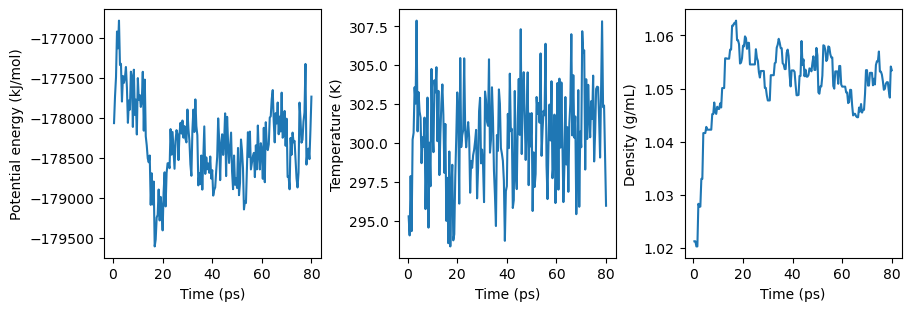

In [112]:
# Create plots for potential energy, temperature, and density over time
step, pe, temp, rho = np.loadtxt(DATA / "MDlog.txt", delimiter="\t", usecols=(1, 2, 3, 4)).T
time = step * dt.value_in_unit(picosecond)

figure = plt.figure(figsize=(9, 3), layout="constrained")

axes_pe = figure.add_subplot(1, 3, 1)
axes_pe.plot(time, pe)
axes_pe.set_xlabel("Time (ps)")
axes_pe.set_ylabel("Potential energy (kJ/mol)")

axes_temp = figure.add_subplot(1, 3, 2)
axes_temp.plot(time, temp)
axes_temp.set_xlabel("Time (ps)")
axes_temp.set_ylabel("Temperature (K)")

axes_rho = figure.add_subplot(1, 3, 3)
axes_rho.plot(time, rho)
axes_rho.set_xlabel("Time (ps)")
axes_rho.set_ylabel("Density (g/mL)")

plt.show()

### Visualize the results
To visualize what we have simulated in a movie, we load the topology (`.pdb`) and the trajectory (`.xtc`) files to create an MDAnalysis `universe` representing the simulated system. 
The universe can easily be visualized in its entirety, including the animation of the trajectory. 

[NGL Viewer](http://nglviewer.org/) provides pre-build functions to visualize simulations loaded in common libraries such as MD Analysis.

In [113]:
md_universe = mda.Universe(DATA / "prepared_system.pdb", DATA / "MDtrajectory.xtc")
# Print the number of frames in the trajectory
print(f"Number of frames in the trajectory: {len(md_universe.trajectory)}")
view = nv.show_mdanalysis(md_universe)
view

/home/idade/miniforge3/envs/noteable-biochem-AY2627/lib/python3.13/site-packages/MDAnalysis/coordinates/XDR.py:261: UserWarning: Reload offsets from trajectory
 ctime or size or n_atoms did not match
  warnings.warn(


Number of frames in the trajectory: 200


NGLWidget(max_frame=199)

In [114]:
# In case the above view does not allow for playing the movie, the play-button below 
# can be used to click through the trajectory and mimic the movie functionality
display(view._iplayer)


Although barely noticable in the visualization of this rather short trajectory, depending on the used simulation package/settings proteins can rotate and translate during simulation. This can complicate visual inspection of the trajectory and usually requires an alignment as as prior step to analysis. A common selection for aligning a trajectory on is the protein. Thus, the protein will not deviate from the center and not rotate allowing the observation of unbinding events or conformational changes. 

The [MDAnalysis](https://docs.mdanalysis.org/stable/index.html) framework allows for easy alignment on an atom selection using strings and has built-in simple selection keywords as well, for example "protein", which selects all residues usually belonging to the protein. 

In the next step, we will align the structures of the trajectory (mobile) onto the reference structure. The frame currently active in the reference structure will be used for alignment.

In [115]:
# Set trajectory pointer to first frame as reference
md_universe.trajectory[0]

# in_memory=True is needed to actually modify the loaded trajectory
# if the trajectory is too big for memory, one can write out the aligned trajectory and reload it into a new universe
alignment = align.AlignTraj(mobile=md_universe, reference=md_universe, select="protein", in_memory=True)
alignment.run()

In [116]:
# Print the number of frames in the trajectory
print(f"Number of frames in the trajectory: {len(md_universe.trajectory)}")

view = nv.show_mdanalysis(md_universe)
view

Number of frames in the trajectory: 200


NGLWidget(max_frame=199)

In [117]:
# In case the above view does not allow for playing the movie, the play-button below 
# can be used to click through the trajectory and mimic the movie functionality
display(view._iplayer)

### Analysis of the MD simulation


Protein movements are clearly visible in the animation. However, it is hard to estimate if the protein actually significantly changes its position/conformation. Hence, we will evaluate the relative movement using a more suffisticated method, the calculation of the RMSD.

In [118]:
def rmsd_for_atomgroups(universe, selection1, selection2=None):
    """Calulate the RMSD for selected atom groups.

    Parameters
    ----------
    universe: MDAnalysis.core.universe.Universe
        MDAnalysis universe.I woul
    selection1: str
        Selection string for main atom group, also used during alignment.
    selection2: list of str, optional
        Selection strings for additional atom groups.

    Returns
    -------
    rmsd_df: pandas.core.frame.DataFrame
        DataFrame containing RMSD of the selected atom groups over time. """

    universe.trajectory[0]
    ref = universe
    rmsd_analysis = rms.RMSD(universe, ref, select=selection1, groupselections=selection2)
    rmsd_analysis.run()
    columns = [selection1, *selection2] if selection2 else [selection1]
    rmsd_df = pd.DataFrame((rmsd_analysis.rmsd[:, 2:]), columns=columns).round(2)
    rmsd_df.index.name = "frame"
    return rmsd_df

In [119]:
rmsd = rmsd_for_atomgroups(md_universe, selection1="backbone", selection2=["protein"])
rmsd.head()

/home/idade/miniforge3/envs/noteable-biochem-AY2627/lib/python3.13/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will be removed in MDAnalysis 3.0.0. Please use `results.rmsd` instead.
  warnings.warn(wmsg, DeprecationWarning)


,backbone,protein
frame,,
0,0.00,0.00
1,0.44,0.57
2,0.43,0.60
3,0.52,0.68
4,0.55,0.70


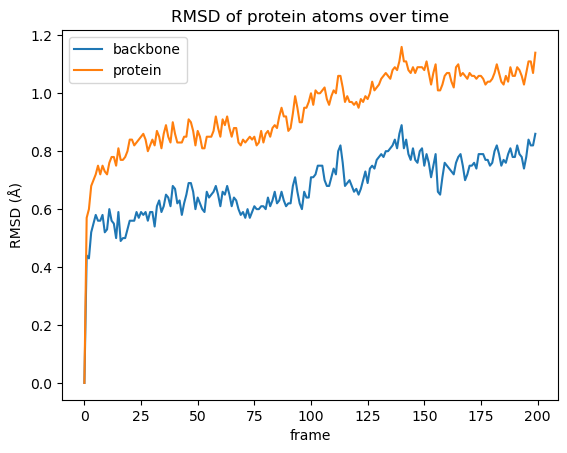

In [120]:
rmsd.plot(title="RMSD of protein atoms over time")
plt.ylabel("RMSD (Å)");

What can we see in the plot:

* There are only slight conformational changes in the backbone during the simulation, which is not surprising since the protein was superimposed w.r.t. the backbone. 
* Including the protein side chains in RMSD calculation lead to more movement, when compared to the protein backbone only.

While RMSD quantifies the overall structural deviation of the protein over time, the root mean square fluctuation (RMSF) measures the mobility of individual residues throughout the simulation. RMSF is commonly calculated for Cα atoms and provides residue-level information about structural flexibility. Regions with low RMSF values are generally more rigid and structurally stable, whereas regions with high RMSF values exhibit greater conformational variability. 

Here, we calculate the RMSF for all Cα atoms in the aligned trajectory and plot the residue-specific fluctuations across the protein sequence.

In [121]:
ca_atoms = md_universe.select_atoms("name CA")
rmsf = rms.RMSF(ca_atoms).run()

rmsf_df = pd.DataFrame({"residue": ca_atoms.resids,"rmsf": rmsf.results.rmsf})
rmsf_df.head()

,residue,rmsf
0,1,0.497546
1,2,0.398848
2,3,0.363636
3,4,0.443306
4,5,0.374537


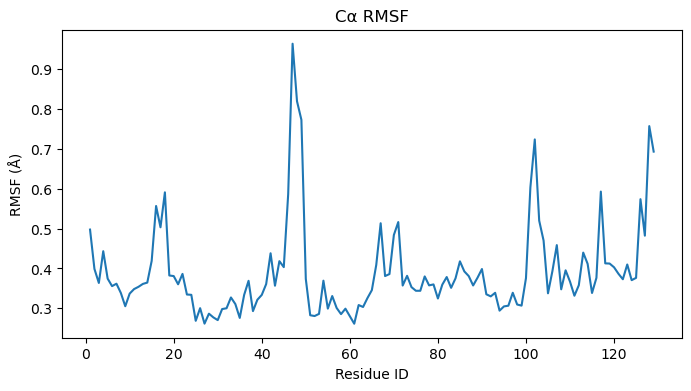

In [122]:
plt.figure(figsize=(8, 4))
plt.plot(rmsf_df["residue"], rmsf_df["rmsf"])

plt.xlabel("Residue ID")
plt.ylabel("RMSF (Å)")
plt.title("Cα RMSF")

plt.show()

Let's have a closer look at which type of amino acids are more flexible than others

In [123]:
# Create a DataFrame that links the RMSF values to the corresponding residue names and chain IDs
rmsf_df = pd.DataFrame({"chain": ca_atoms.chainIDs, 
                        "residue_name": ca_atoms.resnames,
                        "residue_id": ca_atoms.resids,
                        "rmsf": rmsf.results.rmsf})
rmsf_df.sort_values("rmsf", ascending=False)

,chain,residue_name,residue_id,rmsf
46,A,THR,47,0.963758
47,A,ASP,48,0.819480
48,A,GLY,49,0.772866
127,A,ARG,128,0.757091
101,A,GLY,102,0.723715
...,...,...,...,...
34,A,GLU,35,0.275955
29,A,CYS,30,0.270441
24,A,LEU,25,0.268699
26,A,ASN,27,0.261618


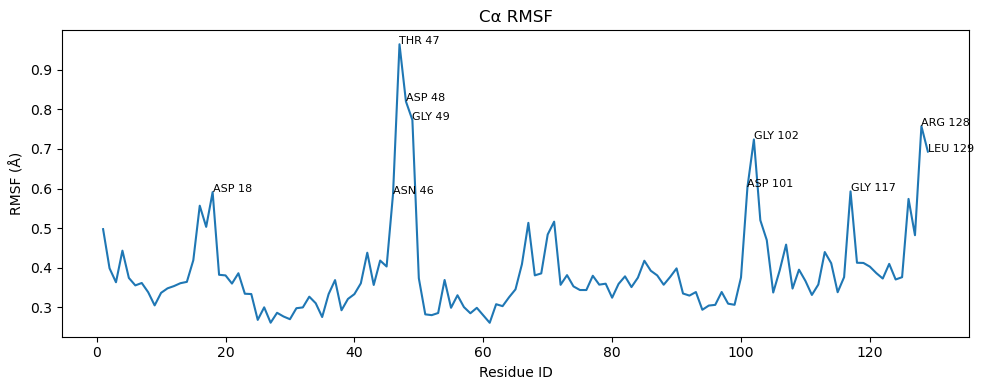

In [124]:
# We add the top 10 most flexible residues to the plot 
plt.figure(figsize=(10, 4))

plt.plot(rmsf_df["residue_id"],rmsf_df["rmsf"])

# Label the 10 most flexible residues
top_residues = rmsf_df.nlargest(10, "rmsf")
for _, row in top_residues.iterrows():
    label = (f"{row['residue_name']} {row['residue_id']}")

    plt.annotate( label, (row["residue_id"], row["rmsf"]), fontsize=8)

plt.xlabel("Residue ID")
plt.ylabel("RMSF (Å)")
plt.title("Cα RMSF")

plt.tight_layout()
plt.show()

The RMSF values can be examined both numerically and graphically. The table lists the calculated fluctuations for each residue and makes it easy to identify the most mobile parts of the protein. In this simulation, the highest RMSF values are observed for residues such as GLY 102, ASN 103, GLY 49, and PRO 70, indicating that these regions exhibit greater conformational flexibility than the rest of the protein.

The RMSF profile provides a residue-by-residue view of protein dynamics. Most residues display fluctuations between approximately 0.3 and 0.6 Å, suggesting a largely stable protein structure over the course of the simulation. In contrast, the pronounced peaks highlight localized flexible regions that may correspond to loops, solvent-exposed segments, or regions undergoing larger conformational motions.

It is common for residues located near the N- and C-termini of a protein to exhibit elevated RMSF values, since these regions are often less constrained than the structured protein core. In the RMSF plot, increased fluctuations can indeed be observed toward the protein termini, alongside several internal flexible regions.

Such analyses are useful for identifying structurally stable and flexible regions of a protein, which can help interpret experimental observations, characterize protein dynamics, and identify regions potentially relevant for molecular recognition or ligand binding.

## Discussion

We have successfully performed an MD simulation of a protein ligand complex. However, we simulated only a considerably short time to keep the execution time of the talktorial short. To address critical questions in drug design, longer simulations are often required.  
MD simulations are still too computationally costly to be useful for this purpose. Thus, so-called enhanced sampling methods were developed, that aim to accelerate the conformational sampling. Some of the most common methods are discussed in the **Further reading** section below.   
Furthermore, we did not include an equilibration step, which is commonly used to slowly heat up the system from 0 to 300 K before starting the simulation and might be important when simulating more sensitive systems including lipid bilayers. The protonation of ligand and protein was done separately, which is suboptimal, since protonation states of protein residues and ligand affect each other. However, we did not find a free and open-source solution meeting all requirements. Suggestions are very welcome!  
If you want to learn how to visualize and analyze the trajectory, you can refer to **Talktorial T020** in this repository.

## Quiz

* Which inter- and intramolecular forces are being considered in the AMBER force field? Can you think of any forces not taken into account?
* Would you expect to see the exact same simulation results when running the notebook twice with the same parameters?
* Try doing a short (10ps, snapshot every 1ps) simulation of a protein without a ligand. You can find a broad variety of structures on [PDB](https://www.rcsb.org/) or you can use the EGFR kinase and remove the ligand.

## Further reading

### Enhanced sampling methods

In theory, unbiased MD simulations should be capable of simulating binding and unbinding events of a drug molecule and its macromolecular target. However, the timescale of binding and unbinding events lies in the millisecond to second range. Enhanced sampling methods aim to accelerate the conformational sampling ([_J Med Chem._ 2016, **59(9)**, 4035-61](https://doi.org/10.1021/acs.jmedchem.5b01684)).

One of these is **Free energy perturbation (FEP)** (also called alchemical free energy calculation), which computes the free energy difference when going from a state A to another state B. It is often employed in lead optimization to evaluate small modification at the ligand, that may boost the binding affinity for the desired target. The ligand from state A is thereby gradually transformed into the ligand of state B by simulating several intermediate ("alchemical") states ([alchemistry](http://www.alchemistry.org/wiki/Main_Page)). 

Another technique for free-energy calculations is **Umbrella sampling (US)**. US enforces sampling along a collective variable (CV) by performing staged simulations with an energetic bias. The bias usually takes the form of a harmonic potential, hence the term "umbrella". Its goal is to sample high-energy regions along the CV. However, the use in drug design is limited by the high computational cost.

In contrast, **Steered MD (SMD)** follows a different approach: it applies external forces to the system. Those forces are time-dependent and facilitate the unbinding of the ligand from the target. The SMD calculates the final force exerted on the system. The unbinding force profile can then be used to filter hits from docking calculations and to discriminate active from inactive molecules.